In [1]:
!pip install torchinfo

# Import Libraries

In [2]:
import time
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import cv2
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms
from torchinfo import summary
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score
import PIL
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import OrderedDict
import platform
import psutil
import random
import glob
from tqdm import tqdm
from PIL import Image
from torchvision import transforms
from torchvision.transforms import ColorJitter, RandomRotation, RandomResizedCrop
from torchvision.transforms.functional import gaussian_blur
from PIL import ImageOps
import seaborn as sns

# Configuration

In [3]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB


# Variables

In [4]:
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data_dir = "/kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)"
output_dir = "/kaggle/working/processed-dataset"  
checkpoints_path = "/kaggle/working/"
os.makedirs(output_dir, exist_ok=True)

train_batch = 32
test_batch = 16
total_class = 3
learning_rate = 0.0001
decay = 1e-4
epoch = 100
patience = 100

# Explore Dataset

In [5]:
import os
import pandas as pd

def load_split(base_dir):
    file_paths = []
    labels = []

    classes = ["all", "normal"]   # folder names

    for class_name in classes:
        class_dir = os.path.join(base_dir, class_name)

        for image_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, image_name)

            if os.path.isfile(img_path):
                file_paths.append(img_path)
                labels.append(class_name)

    return pd.DataFrame({
        "file_path": file_paths,
        "label": labels
    })


data_dir = "/kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)"  # adjust if needed
data = load_split(data_dir)

print(data.head())
print("Total images:", len(data))

                                           file_path label
0  /kaggle/input/datasets/imasifahmed/c-nmc-2019-...   all
1  /kaggle/input/datasets/imasifahmed/c-nmc-2019-...   all
2  /kaggle/input/datasets/imasifahmed/c-nmc-2019-...   all
3  /kaggle/input/datasets/imasifahmed/c-nmc-2019-...   all
4  /kaggle/input/datasets/imasifahmed/c-nmc-2019-...   all
Total images: 10661


In [6]:
train_dataframe, temp_dataframe = train_test_split(
    data, 
    test_size=0.30, 
    stratify=data['label'], 
    random_state=42
)

validation_dataframe, test_dataframe = train_test_split(
    temp_dataframe, 
    test_size=0.50, 
    stratify=temp_dataframe['label'], 
    random_state=42
)

Dataset Split Ratios
Train: 7462 images (69.99%)
Test: 1600 images (15.01%)
Validation: 1599 images (15.00%)


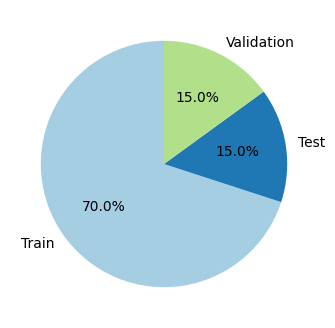

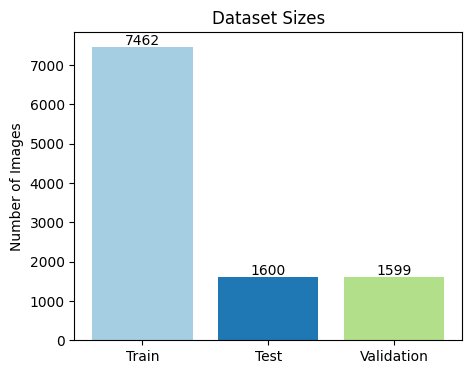

In [7]:
sizes = {
    "Train": len(train_dataframe),
    "Test": len(test_dataframe),
    "Validation": len(validation_dataframe)
}

total = sum(sizes.values())
ratios = {k: (v / total) * 100 for k, v in sizes.items()}

print("Dataset Split Ratios")
for split in sizes.keys():
    print(f"{split}: {sizes[split]} images ({ratios[split]:.2f}%)")

plt.figure(figsize=(4, 4))
plt.pie(
    sizes.values(),
    labels=sizes.keys(),
    autopct="%.1f%%",
    startangle=90,
    colors=["#a6cee3", "#1f78b4", "#b2df8a"]
)
plt.show()

plt.figure(figsize=(5, 4))
plt.bar(sizes.keys(), sizes.values(), color=["#a6cee3", "#1f78b4", "#b2df8a"])
plt.ylabel("Number of Images")
plt.title("Dataset Sizes")
y_max = max(sizes.values()) * 1.05 
plt.ylim(0, y_max)
for i, v in enumerate(sizes.values()):
    plt.text(i, v + total*0.005, str(v), ha='center')  
plt.show()

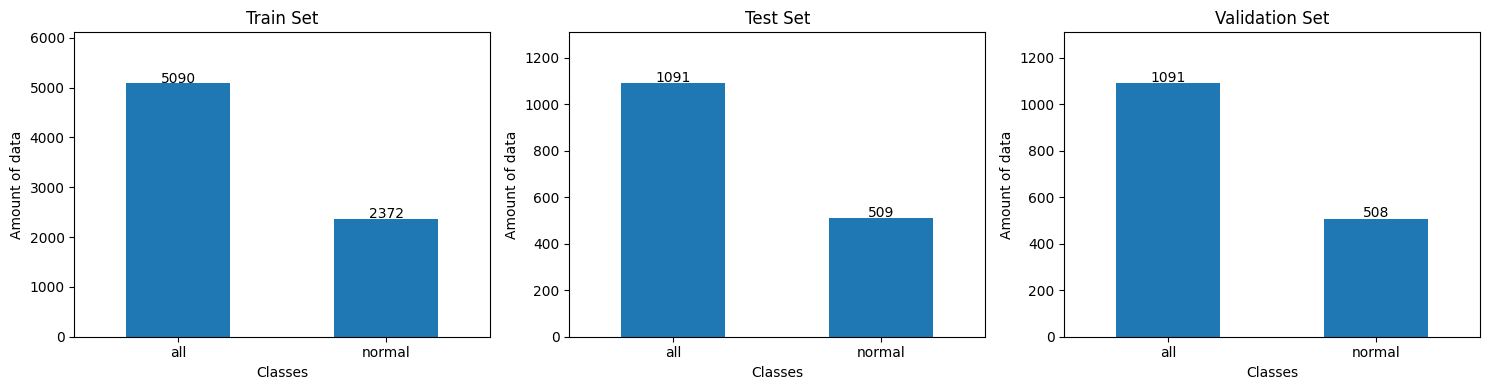

In [8]:
def class_distribution(train_df, test_df, val_df):
    datasets = {
        "Train": train_df,
        "Test": test_df,
        "Validation": val_df
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for ax, (split_name, df) in zip(axes, datasets.items()):
        class_counts = df['label'].value_counts()

        class_counts.plot(kind='bar', ax=ax)
        ax.set_xlabel('Classes')
        ax.set_ylabel('Amount of data')
        ax.set_title(f'{split_name} Set')
        ax.set_xticks(range(len(class_counts)))
        ax.set_xticklabels(class_counts.index, rotation=360)
        
        for i, count in enumerate(class_counts):
            ax.text(i, count + 5, str(count), ha='center')
        ax.set_ylim(0, max(class_counts) * 1.2)
    
    plt.tight_layout()
    plt.show()

class_distribution(train_dataframe, test_dataframe, validation_dataframe)

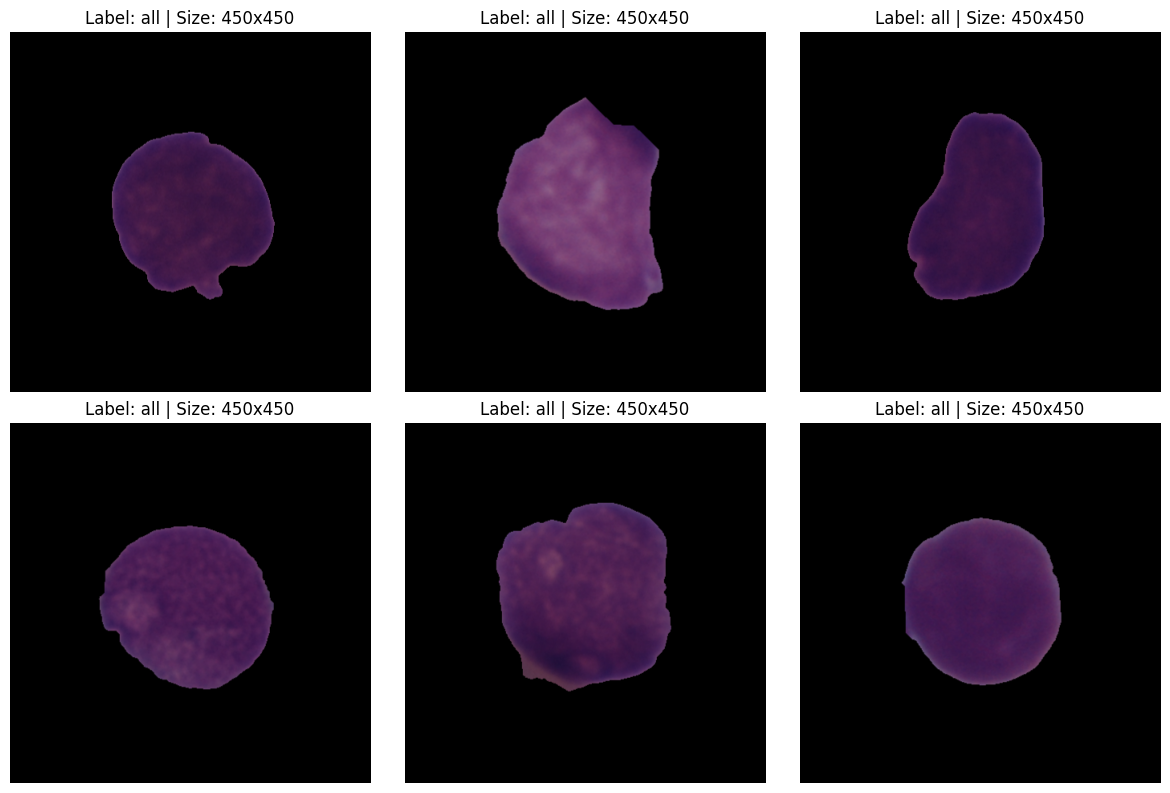

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))  
axes = axes.flatten() 

for ax in axes:
    random_index = random.randint(0, len(train_dataframe) - 1)
    random_row = train_dataframe.iloc[random_index]

    file_path = random_row['file_path']
    label = random_row['label']

    image = Image.open(file_path)
    width, height = image.size

    ax.imshow(image)
    ax.set_title(f"Label: {label} | Size: {width}x{height}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Data Preprocessing 

In [10]:
sample_image_path = train_dataframe['file_path'].iloc[0]
img = Image.open(sample_image_path)
num_channels = len(img.getbands())
print(f"Number of channels: {num_channels}")

Number of channels: 3


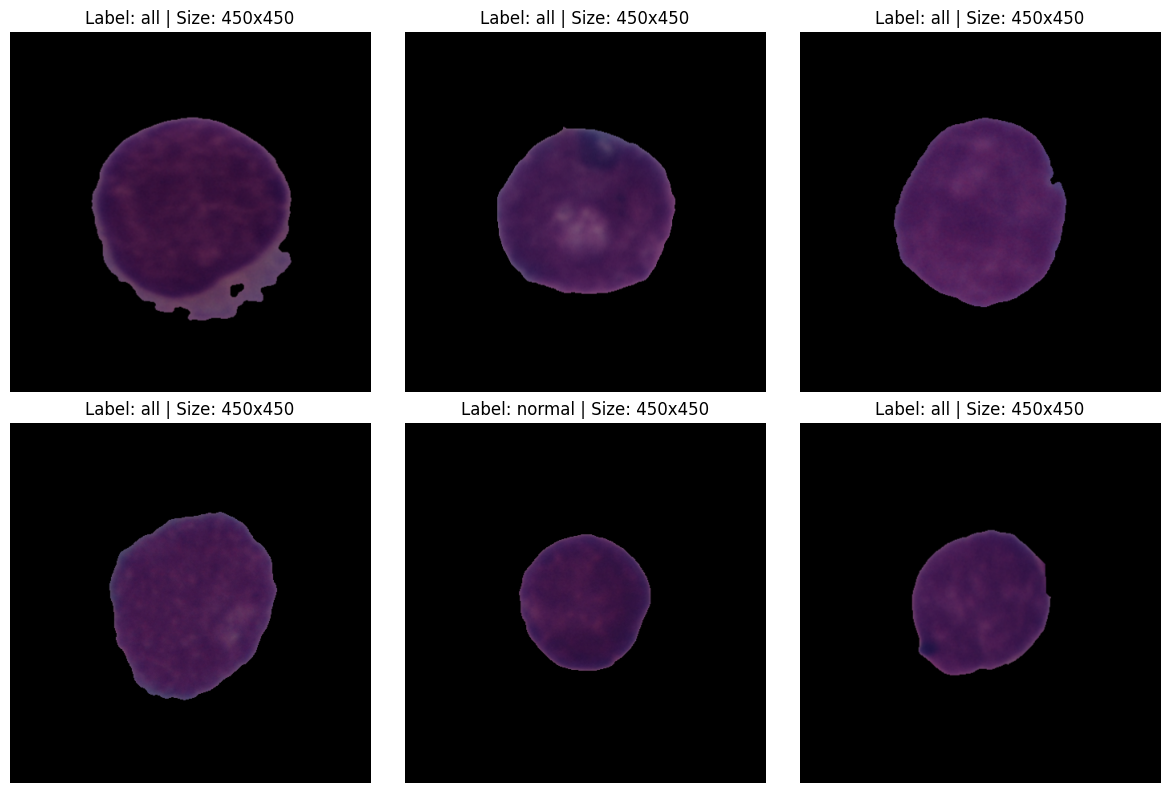

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))  
axes = axes.flatten() 

for ax in axes:
    random_index = random.randint(0, len(train_dataframe) - 1)
    random_row = train_dataframe.iloc[random_index]

    file_path = random_row['file_path']
    label = random_row['label']

    image = Image.open(file_path)
    width, height = image.size

    ax.imshow(image)
    ax.set_title(f"Label: {label} | Size: {width}x{height}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Dataset Class, Data Transform and Dataloader

In [12]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, normalize, is_lb=False):
        self.dataframe = dataframe
        self.normalize = normalize
        self.is_lb = is_lb
        unique_labels = sorted(self.dataframe['label'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['file_path']
        image = PIL.Image.open(img_path)

        if self.is_lb:
            label = self.label_map[self.dataframe.iloc[index]['label']]
            return self.normalize(image), label
        else:
            return self.normalize(image), self.normalize(image)

In [13]:
def data_transfrom():

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    train_transform = transforms.Compose([
        transforms.RandomRotation(degrees=15),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomResizedCrop(224, scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.GaussianBlur(kernel_size=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    train_dataset = ImageDataset (
        train_dataframe,
        train_transform,
        is_lb=True
    )

    valid_dataset = ImageDataset(
        validation_dataframe,
        transform,
        is_lb=True
    )

    test_dataset = ImageDataset(
        test_dataframe,
        transform,
        is_lb=True
    )

    print("Label encoding:")
    for label, idx in train_dataset.label_map.items():
        print(f"{label} -> {idx}")
        
    train_dataloader = DataLoader(train_dataset, batch_size = train_batch, shuffle=True, num_workers=2)
    validation_dataloader = DataLoader(valid_dataset, batch_size = test_batch, shuffle=False, num_workers=2)
    test_dataloader = DataLoader(test_dataset, batch_size = test_batch, shuffle=False, num_workers=2)

    return train_dataloader, validation_dataloader, test_dataloader

train_dataloader, validation_dataloader, test_dataloader = data_transfrom()

Label encoding:
all -> 0
normal -> 1


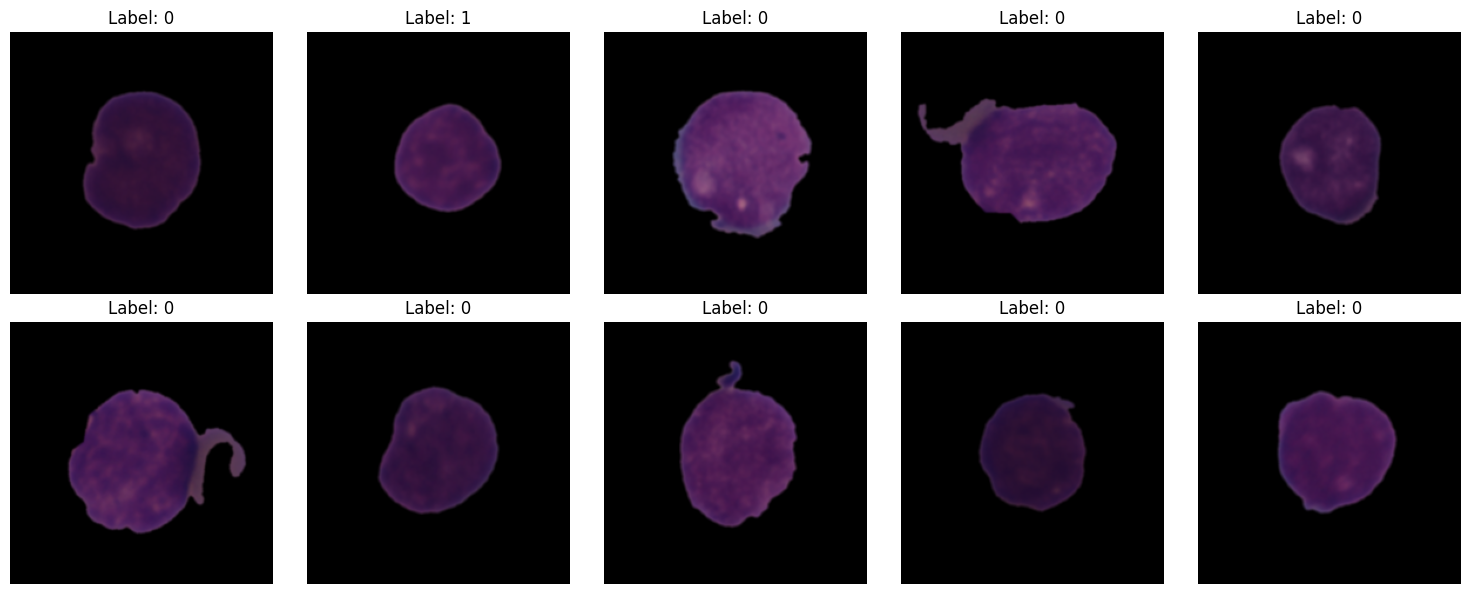

In [14]:
def augmented_samples(dataloader, num_images=10):
    images, labels = next(iter(dataloader))  

    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    images = images * std[None, :, None, None] + mean[None, :, None, None]
    images = torch.clamp(images, 0, 1)  

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i, ax in enumerate(axes.flat):
        if i >= num_images:
            break
        img = images[i].permute(1, 2, 0).cpu().numpy() 
        label = labels[i].item()
        ax.imshow(img)
        ax.set_title(f"Label: {label}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

augmented_samples(train_dataloader)

# Deep Learning Model

In [15]:
import torch.nn as nn

class BrainCancerNet(nn.Module):
    def __init__(self, num_classes):
        super(BrainCancerNet, self).__init__()
        
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Conv Block 4
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Conv Block 5
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

      
        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)      
        x = self.classifier(x)
        return x

In [16]:
num_classes = total_class  
model = BrainCancerNet(num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=decay)
criterion = nn.CrossEntropyLoss()
summary(model, input_size=(train_batch, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
BrainCancerNet                           [32, 3]                   --
├─Sequential: 1-1                        [32, 512, 7, 7]           --
│    └─Conv2d: 2-1                       [32, 32, 224, 224]        896
│    └─BatchNorm2d: 2-2                  [32, 32, 224, 224]        64
│    └─ReLU: 2-3                         [32, 32, 224, 224]        --
│    └─MaxPool2d: 2-4                    [32, 32, 112, 112]        --
│    └─Conv2d: 2-5                       [32, 64, 112, 112]        18,496
│    └─BatchNorm2d: 2-6                  [32, 64, 112, 112]        128
│    └─ReLU: 2-7                         [32, 64, 112, 112]        --
│    └─MaxPool2d: 2-8                    [32, 64, 56, 56]          --
│    └─Conv2d: 2-9                       [32, 128, 56, 56]         73,856
│    └─BatchNorm2d: 2-10                 [32, 128, 56, 56]         256
│    └─ReLU: 2-11                        [32, 128, 56, 56]         --
│   

# Model Training

In [17]:
start_time = time.time()

def train_model(model, criterion, optimizer, train_dataloader, validation_dataloader,
                num_epochs=10, early_stop_patience=5, checkpoints_path="checkpoints"):

    os.makedirs(checkpoints_path, exist_ok=True)

    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    best_val_acc = 0.0
    best_epoch = 0
    consecutive_no_improvement = 0
    num_epochs_loss_greater = 0

    for epoch in range(num_epochs):

        # ---------------- TRAIN ----------------
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        progress_bar = tqdm(train_dataloader)

        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            progress_bar.set_description(f"Epoch {epoch+1}/{num_epochs}")
            progress_bar.set_postfix(
                loss=running_loss / max(total_train,1),
                acc=correct_train / max(total_train,1)
            )

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)

        print(f"Training Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f}")

        # ---------------- VALIDATION ----------------
        model.eval()

        running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():

            for inputs, labels in validation_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, predicted = torch.max(outputs, 1)

                running_loss += loss.item() * inputs.size(0)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / total_val
        epoch_val_acc = correct_val / total_val

        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)

        print(f"Validation Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f}")

        # ---------------- SAVE BEST MODEL ----------------
        if epoch_val_acc > best_val_acc:

            best_val_acc = epoch_val_acc
            best_epoch = epoch + 1
            consecutive_no_improvement = 0

            filepath = os.path.join(checkpoints_path, "best_model.pt")

            checkpoint = {
                "epoch": best_epoch,
                "model_weight": model.state_dict(),
                "optimizer_state": optimizer.state_dict()
            }

            torch.save(checkpoint, filepath)

            print(f"✅ Best model saved at epoch {best_epoch} (Val Acc: {best_val_acc:.4f})")

        else:
            consecutive_no_improvement += 1
            print(f"EARLY STOP COUNTER: {consecutive_no_improvement}")

        # ---------------- LOSS CHECK ----------------
        if epoch_val_loss > epoch_train_loss:
            num_epochs_loss_greater += 1
        else:
            num_epochs_loss_greater = 0

        # ---------------- EARLY STOP ----------------
        if (consecutive_no_improvement >= early_stop_patience or
            num_epochs_loss_greater >= early_stop_patience):

            print(f"🛑 Early stopping triggered at epoch {epoch+1}")
            break

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history


# ---- RUN TRAINING ----
train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(
    model,
    criterion,
    optimizer,
    train_dataloader,
    validation_dataloader,
    num_epochs=epoch,
    early_stop_patience=patience,
    checkpoints_path=checkpoints_path
)


# ---- TRAINING TIME ----
end_time = time.time()
training_time = end_time - start_time

print(f"Training Time: {training_time:.2f} seconds ---> {training_time/60:.2f} minutes")


# ---- SAVE TRAINING LOG ----
data = {
    "Epoch": list(range(1, len(train_loss_history) + 1)),
    "Train Loss": train_loss_history,
    "Train Accuracy": train_acc_history,
    "Validation Loss": val_loss_history,
    "Validation Accuracy": val_acc_history
}

history = pd.DataFrame(data)

history.to_excel("/kaggle/working/training_logs.xlsx", index=False)

print("Training log saved to /kaggle/working/training_logs.xlsx")

Epoch 1/100: 100%|██████████| 234/234 [01:08<00:00,  3.42it/s, acc=0.787, loss=0.492]

Training Loss: 0.4923 | Acc: 0.7865


Validation Loss: 0.8089 | Acc: 0.5003
✅ Best model saved at epoch 1 (Val Acc: 0.5003)


Epoch 2/100: 100%|██████████| 234/234 [00:40<00:00,  5.75it/s, acc=0.837, loss=0.398]

Training Loss: 0.3982 | Acc: 0.8373


...

Training Loss: 0.1452 | Acc: 0.9433


Validation Loss: 1.3748 | Acc: 0.6892
EARLY STOP COUNTER: 22


Epoch 100/100: 100%|██████████| 234/234 [00:42<00:00,  5.57it/s, acc=0.942, loss=0.151]

Training Loss: 0.1512 | Acc: 0.9416


Validation Loss: 1.1337 | Acc: 0.6923
EARLY STOP COUNTER: 23
🛑 Early stopping triggered at epoch 100
Training Time: 4785.10 seconds ---> 79.75 minutes
Training log saved to /kaggle/working/training_logs.xlsx


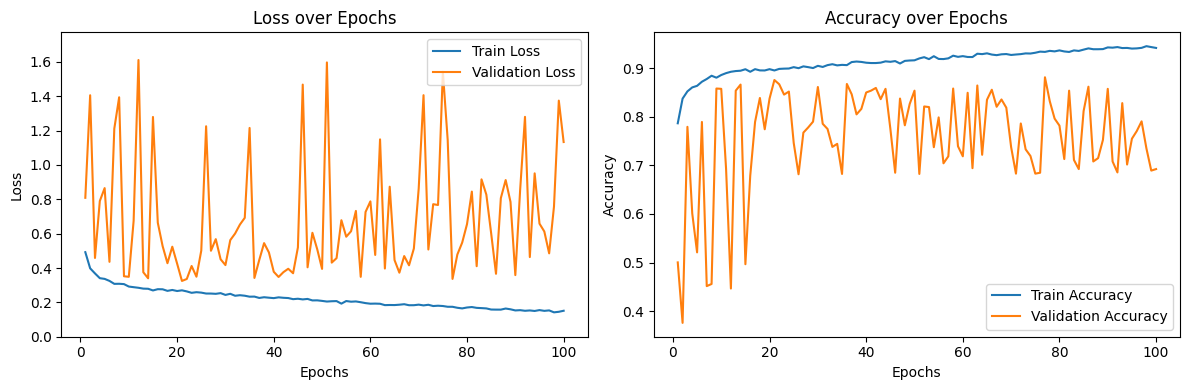

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, label='Train Loss')
plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend(loc='upper right')
plt.ylim(0, max(max(train_loss_history), max(val_loss_history)) * 1.1)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc_history) + 1), train_acc_history, label='Train Accuracy')
plt.plot(range(1, len(val_acc_history) + 1), val_acc_history, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Load Saved Checkpoints

In [19]:
best_checkpoint_path = os.path.join(checkpoints_path, "best_model.pt")

if os.path.exists(best_checkpoint_path):

    checkpoint = torch.load(best_checkpoint_path, map_location=device)

    best_epoch = checkpoint["epoch"]
    model.load_state_dict(checkpoint["model_weight"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    print(f"✅ Loaded best model from epoch {best_epoch}")

else:
    print("❌ No checkpoint found. Training may not have saved a model.")

✅ Loaded best model from epoch 77


# Evaluation

In [20]:
def evaluate_model(model, criterion, dataloader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [21]:
start_time = time.time()

test_loss, test_accuracy = evaluate_model(model, criterion, test_dataloader)
print(f"Test Accuracy: {test_accuracy:.3f}")

end_time = time.time()
test_time = end_time - start_time
print(f"Test Time: {test_time:.2f} seconds ---> {test_time/60:.2f} minutes")

Test Accuracy: 0.864
Test Time: 11.68 seconds ---> 0.19 minutes


In [22]:
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# -------------------------------
# Class Accuracy Function
# -------------------------------
def class_accuracy(model, dataloader, num_classes):

    class_correct = [0] * num_classes
    class_total = [0] * num_classes

    model.eval()

    with torch.no_grad():
        for inputs, labels in dataloader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            correct = (predicted == labels)

            for i in range(len(labels)):
                label = labels[i].item()
                class_correct[label] += correct[i].item()
                class_total[label] += 1

    class_acc = [
        class_correct[i] / class_total[i] if class_total[i] > 0 else 0
        for i in range(num_classes)
    ]

    return class_acc


# -------------------------------
# Collect Predictions
# -------------------------------
y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for inputs, labels in test_dataloader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())


y_true = np.array(y_true)
y_pred = np.array(y_pred)


# -------------------------------
# Detect Classes Automatically
# -------------------------------
labels = np.unique(y_true)
class_names = [str(i) for i in labels]


# -------------------------------
# Classification Report
# -------------------------------
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=class_names
    )
)


# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)


# -------------------------------
# Class Accuracy
# -------------------------------
total_class = len(labels)

class_acc = class_accuracy(model, test_dataloader, total_class)

print("\nClass Accuracy:")

for i in range(total_class):
    print(f"Class {i} Accuracy: {class_acc[i]:.4f}")


Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1091
           1       0.85      0.70      0.77       509

    accuracy                           0.86      1600
   macro avg       0.86      0.82      0.84      1600
weighted avg       0.86      0.86      0.86      1600

Confusion Matrix:
[[1029   62]
 [ 155  354]]

Class Accuracy:
Class 0 Accuracy: 0.9432
Class 1 Accuracy: 0.6955


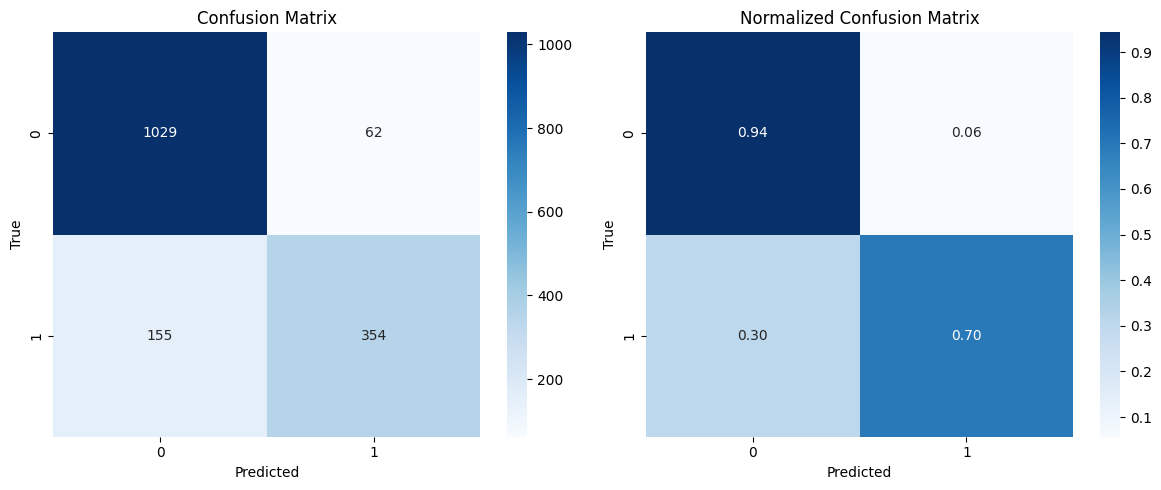

In [23]:
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.subplot(1, 2, 2)
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')

plt.tight_layout()
plt.show()

# Explainable AI (GradCAM)

In [24]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        # forward hook
        forward_handle = self.target_layer.register_forward_hook(forward_hook)

        # ✅ FIX: use full backward hook instead of deprecated one
        backward_handle = self.target_layer.register_full_backward_hook(backward_hook)

        self.hook_handles.append(forward_handle)
        self.hook_handles.append(backward_handle)

    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()

    def generate_cam(self, input_tensor, target_class):
        self.model.eval()
        input_tensor.requires_grad_(True)

        output = self.model(input_tensor)
        self.model.zero_grad()

        class_score = output[:, target_class]
        class_score.backward()

        gradients = self.gradients
        activations = self.activations

        # Global Average Pooling of gradients
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

        cam = torch.sum(weights * activations, dim=1)
        cam = F.relu(cam)

        cam = cam.squeeze().cpu().numpy()

        cam -= np.min(cam)
        cam /= (np.max(cam) + 1e-8)

        cam = np.power(cam, 0.5)

        cam = cv2.resize(cam, (224, 224))

        return cam

In [25]:
def denormalize_image(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor


def show_gradcam(model, dataloader, device, target_layer, classes, num_samples=10,
                 mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225],
                 start_index=0):

    gradcam = GradCAM(model, target_layer)
    all_inputs = []
    all_labels = []

    for inputs, labels in dataloader:
        for i in range(inputs.size(0)):
            all_inputs.append(inputs[i])
            all_labels.append(labels[i])
        if len(all_inputs) >= start_index + num_samples:
            break

    if len(all_inputs) < start_index + num_samples:
        print("Not enough samples in the dataloader.")
        return

    plt.figure(figsize=(8, num_samples * 3))

    for idx in range(start_index, start_index + num_samples):

        input_tensor = all_inputs[idx].unsqueeze(0).to(device)
        label = all_labels[idx].to(device).item()

        output = model(input_tensor)
        pred_class = output.argmax(dim=1).item()

        cam = gradcam.generate_cam(input_tensor, pred_class)

        # Normalize CAM
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)

        input_denorm = denormalize_image(all_inputs[idx].clone().cpu(), mean, std)
        img_np = input_denorm.numpy().transpose(1, 2, 0)
        img_np = np.clip(img_np, 0, 1)
        img_uint8 = np.uint8(255 * img_np)

        # ✅ FIX: Resize CAM to match image size
        cam = cv2.resize(cam, (img_uint8.shape[1], img_uint8.shape[0]))

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)

        overlay = cv2.addWeighted(img_uint8, 0.6, heatmap, 0.4, 0)

        plt.subplot(num_samples, 2, 2 * (idx - start_index) + 1)
        plt.imshow(img_uint8)
        plt.title(f"Original\nLabel: {classes[label]}")
        plt.axis('off')

        plt.subplot(num_samples, 2, 2 * (idx - start_index) + 2)
        plt.imshow(overlay[..., ::-1])
        plt.title(f"Grad-CAM\nPredicted Label: {classes[pred_class]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    gradcam.remove_hooks()

# target_layer = model.features[16]

show_gradcam(
    model=model,
    dataloader=validation_dataloader,
    device=device,
    target_layer=target_layer,
    classes=sorted(train_dataframe['label'].unique()),
    num_samples=5,
    start_index=0
)

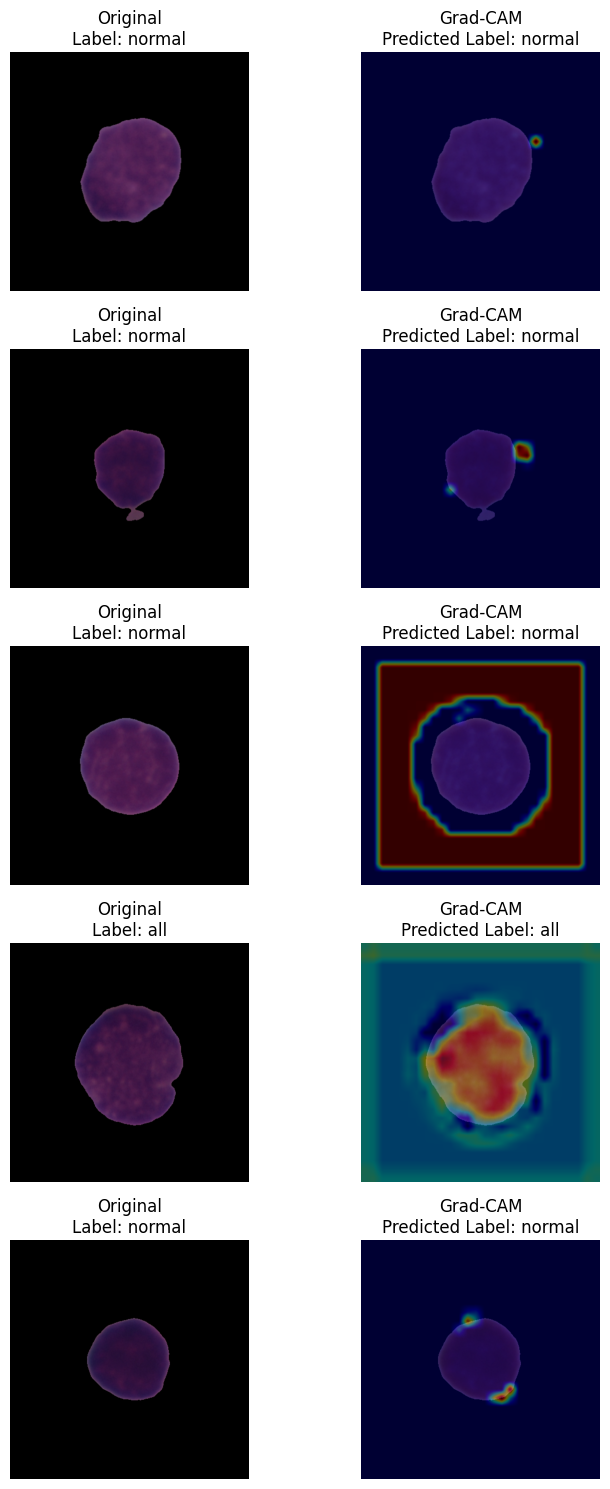

In [26]:
target_layer = model.features[16]

show_gradcam(
    model=model,
    dataloader=validation_dataloader,
    device=device,
    target_layer=target_layer,
    classes=sorted(train_dataframe['label'].unique()),
    num_samples=5,
    start_index=0
)